In [5]:
import pysindy as ps
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)
optimizer = ps.STLSQ(threshold=0.01)
def lotka_volterra(t, state, a, b, c, d):
    x, y = state
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

amountOfData = np.arange(6,1000,step=5)
results = np.zeros(len(amountOfData))
for index,count in enumerate(amountOfData):
    # print(count)
    params = (1.1, 0.4, 0.4, 0.1)
    initial_pop = [10, 5]
    t_span = (0, 100)
    t_eval = np.linspace(0, 100, int(count))

    sol = solve_ivp(
        lotka_volterra,
        t_span,
        initial_pop,
        args=params,
        t_eval=t_eval
    )

    x = sol.y[0]
    y = sol.y[1]
    t = sol.t

    model = ps.SINDy(
        differentiation_method=differentiation_method,
        feature_library=feature_library,
        optimizer=optimizer,
    )
    X = np.stack((x, y), axis=-1)
    model.fit(X, t=t, feature_names=["x", "y"])

    # print("Discovered Equations:")
    # model.print()

    try:
        x_sim = model.simulate(initial_pop, t_eval)

        rmse_x = np.sqrt(np.mean((x_orig - x_sim[:,0])**2))
        results[index] = rmse_x
        x_orig = sol.y[0]
        y_orig = sol.y[1]
        x_simulated = x_sim[:, 0]
        y_simulated = x_sim[:, 1]
        mse_x = np.mean((x_orig - x_simulated)**2)
        mse_y = np.mean((y_orig - y_simulated)**2)
        rmse_x = np.sqrt(mse_x)
        rmse_y = np.sqrt(mse_y)
    except Exception:
        results[index] = np.nan

    results[index] = rmse_x

/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/utils/_axes.py:389: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/utils/_axes.py:389: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/utils/_axes.py:389: RuntimeWarning: overflow encountered in reduce
  results = super().__arr

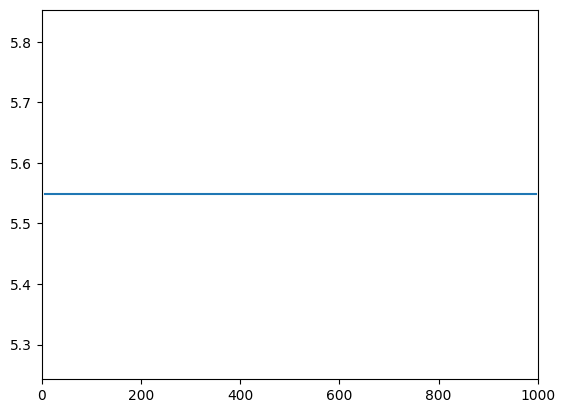

In [14]:
plt.plot(amountOfData,results)
plt.xlim(0,1000)
print()

In [ ]:
amountOfData = np.arange(6, 1000)

rmse_results = np.full(len(amountOfData), np.nan)
coef_error = np.full(len(amountOfData), np.nan)
success = np.zeros(len(amountOfData))

Xi_true = np.array([
    [0.0,  0.0],
    [1.1,  0.0],
    [0.0, -0.4],
    [0.0,  0.0],
    [-0.4, 0.1],
    [0.0,  0.0]
])

for index, count in enumerate(amountOfData):

    params = (1.1, 0.4, 0.4, 0.1)
    initial_pop = [10, 5]

    t_eval = np.linspace(0, 100, count)

    sol = solve_ivp(
        lotka_volterra,
        (0, 100),
        initial_pop,
        args=params,
        t_eval=t_eval
    )

    X = np.stack((sol.y[0], sol.y[1]), axis=-1)

    model = ps.SINDy(
        differentiation_method=differentiation_method,
        feature_library=feature_library,
        optimizer=optimizer,
    )

    try:

        model.fit(X, t=sol.t)

        # -------------------------
        # Coefficient recovery error
        # -------------------------

        Xi_hat = model.coefficients().T

        coef_error[index] = np.linalg.norm(
            Xi_true - Xi_hat,
            ord="fro"
        )

        # -------------------------
        # Trajectory recovery error
        # -------------------------

        x_sim = model.simulate(initial_pop, t_eval)

        rmse_x = np.sqrt(
            np.mean((sol.y[0] - x_sim[:, 0])**2)
        )

        rmse_results[index] = rmse_x

        success[index] = 1

    except Exception:
        pass

/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/utils/_axes.py:389: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/utils/_axes.py:389: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.01) and eliminated all coefficients
  warnings.warn(
/Users/jordan/PycharmProjects/AMP3/.venv/lib/python3.13/site-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.01) and eliminated al

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

ax[0].plot(amountOfData, coef_error)
ax[0].set_ylabel("Coefficient Error")
ax[0].set_title("Coefficient Recovery")

ax[1].plot(amountOfData, rmse_results)
ax[1].set_ylabel("Trajectory RMSE")
ax[1].set_title("Trajectory Error")

ax[2].plot(amountOfData, success)
ax[2].set_ylabel("Success")
ax[2].set_xlabel("Number of Samples")
ax[2].set_title("Simulation Success")

plt.tight_layout()
plt.show()